In [1]:
from qiskit.circuit.library import CXGate, iSwapGate
from qiskit.quantum_info.random import random_unitary
from qiskit.quantum_info import Operator, average_gate_fidelity
from gulps.gulps_synthesis import GulpsDecomposer
from gulps.utils.isa import ISAInvariants
from tqdm import tqdm
from weylchamber import c1c2c3

In [ ]:
gate_set = [
    CXGate(),
    CXGate().power(1 / 2),
    iSwapGate().power(1 / 2),
    iSwapGate().power(1 / 3),
]

costs = [1.0, 1 / 2, 1 / 2, 1 / 3]
decomposer = GulpsDecomposer(gate_set, costs)

In [ ]:
decomposer = GulpsDecomposer(gate_set, costs, precompute_polytopes=True)

In [ ]:
N = 100
# for _ in tqdm(range(N)):
for idx in range(N):
    u = random_unitary(4, seed=2)
    v = Operator(decomposer(u))
    print(average_gate_fidelity(u, v))
    print(c1c2c3(u), c1c2c3(v))
    print("\n")
qc = decomposer(u)
qc.draw()

herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)




/home/evm9/hetero_isas/src/gulps/utils/invariants.py:150: UserWarning: Possible sign difference in c parameter during local equivalence recovery.
  warnings.warn(


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)


herE
0.9889828189999044
(0.81259404, 0.05332171, 0.03744055) (0.18740596, 0.05332171, 0.03744055)




Usage as a TransformationPass

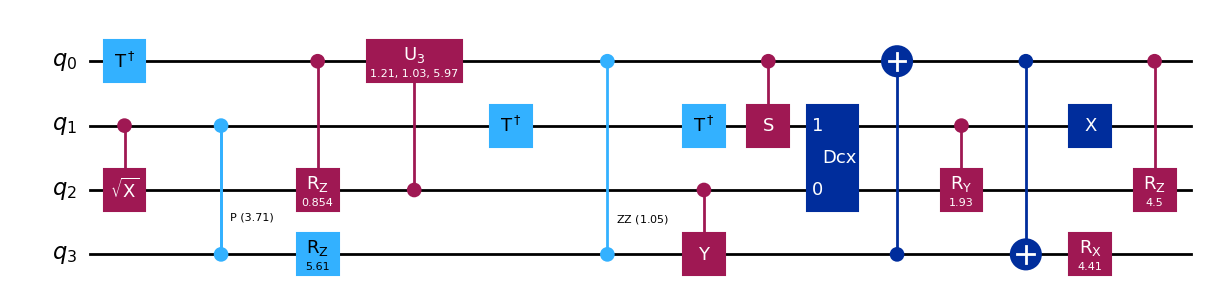

herE
herE
herE
herE
herE
herE
herE
herE
herE
herE
herE
herE


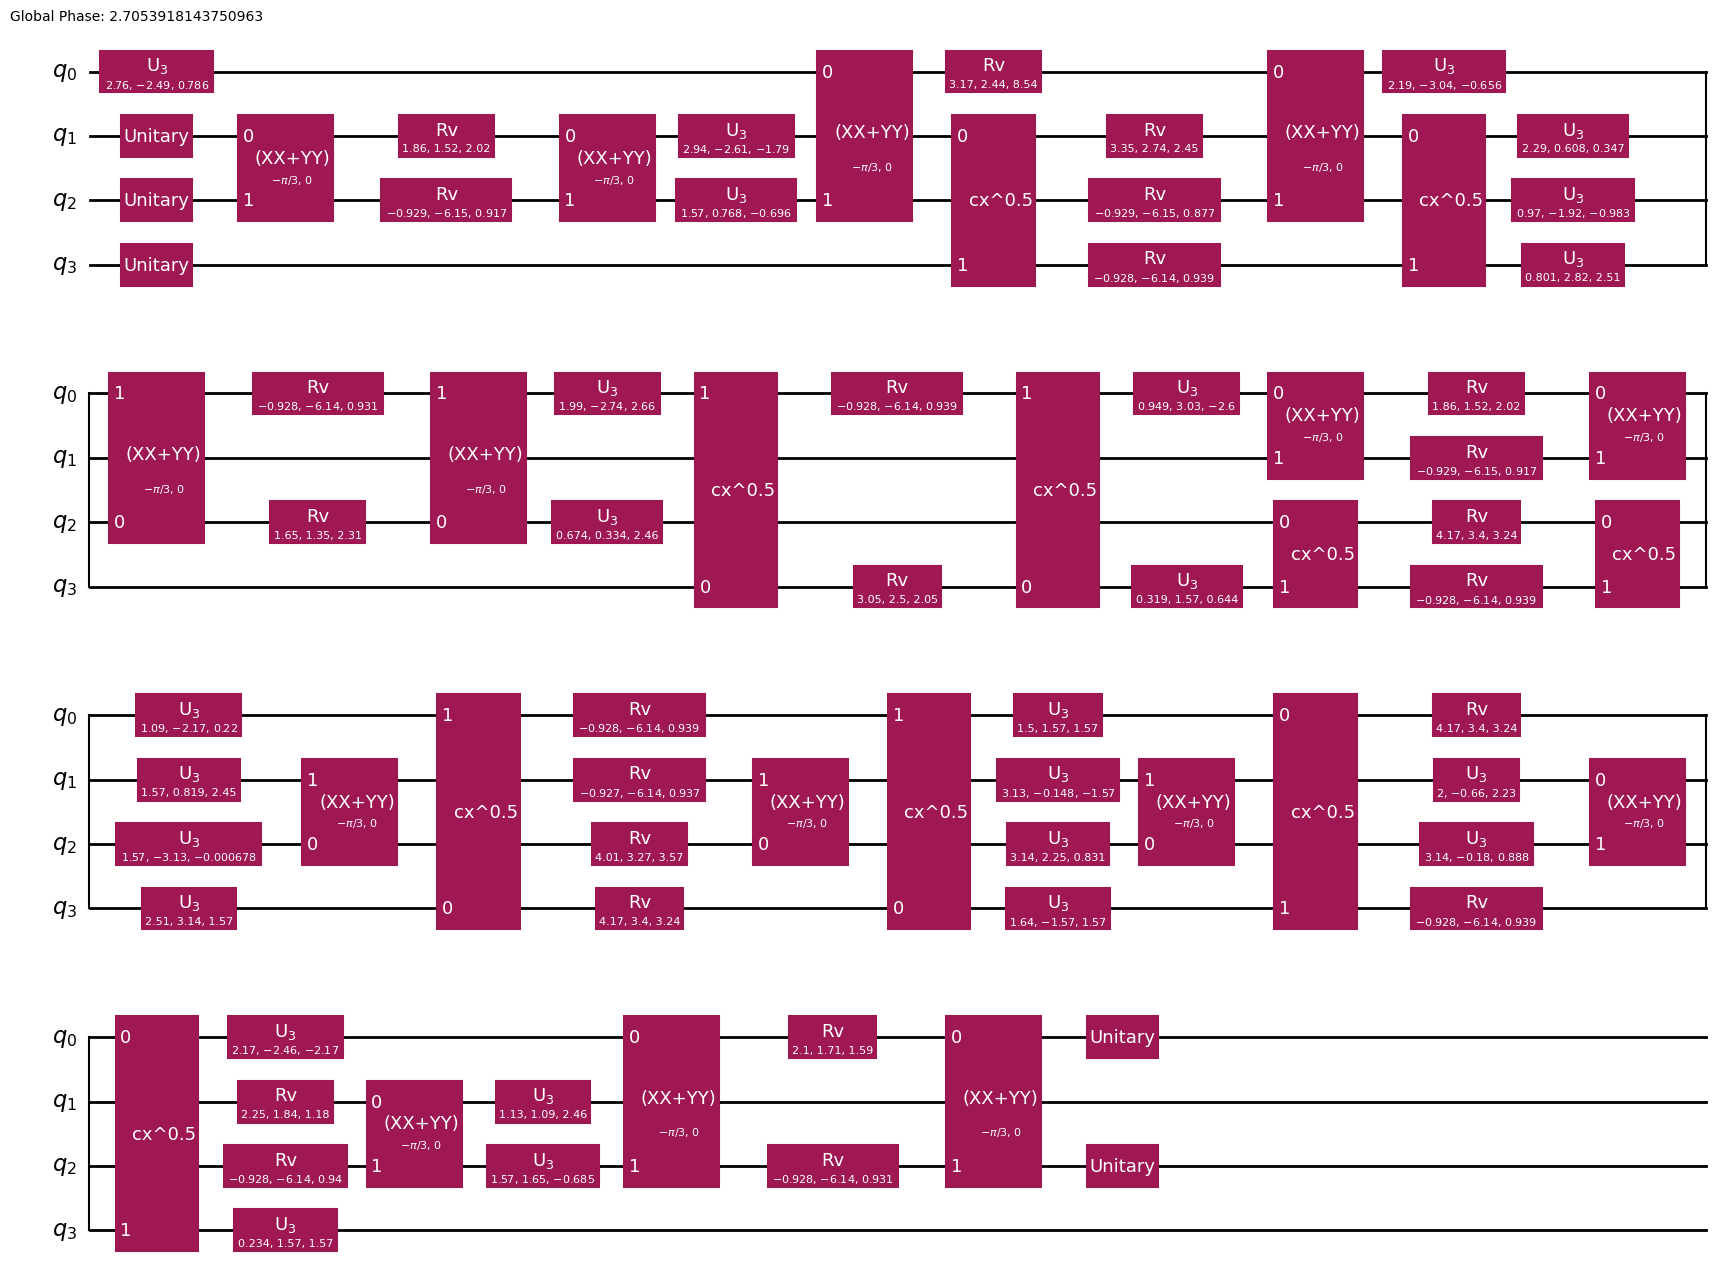

In [38]:
from qiskit.circuit.random import random_circuit
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGatesDecomposition

from gulps.synthesis_pass import GulpsDecompositionPass

input_qc = random_circuit(
    4, 8, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

pm = PassManager(
    [
        GulpsDecompositionPass(gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl")